--- Baseline Linear Regression ---
Coefficients: 
[-4.25467060e+04 -4.23360430e+04  1.15509711e+03 -8.44041848e+00
  1.15830375e+02 -3.67587673e+01  4.16404344e+01  4.02932784e+04]
Train MSE: 4817977906.7658
Test MSE: 4921881237.6282

--- Tuning Results ---
Best Ridge Alpha: 10
Best Lasso Alpha: 10

--- Final Model Comparison ---
Ridge Test MSE: 4921979140.5532
Lasso Test MSE: 4921918805.4619
Lasso Sparse Coefficients: 0 out of 8


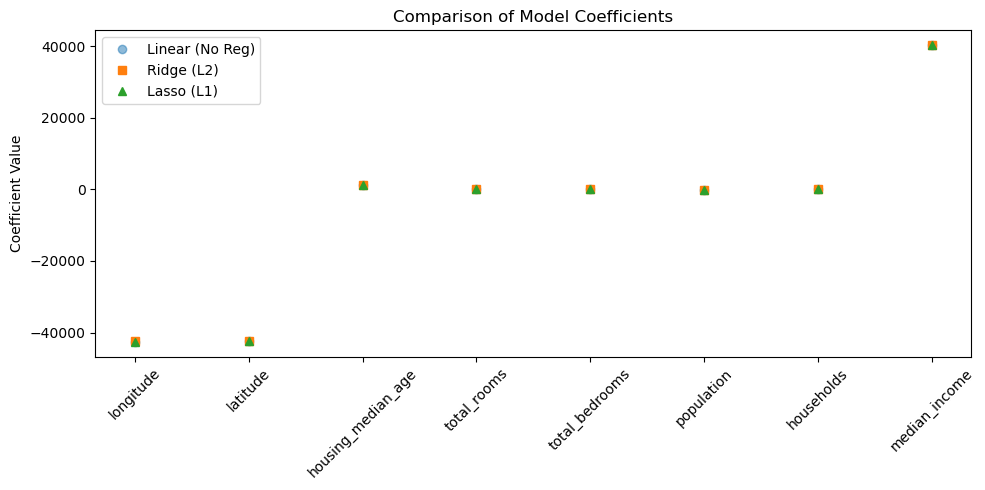

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

# ==========================================
# PART 1: REGRESSION TASK (California Housing)
# ==========================================

# 1. Load Dataset
# Using the local 'housing.csv' file you uploaded
df = pd.read_csv('housing.csv')

# 2. Data Cleaning
# Linear models cannot handle string columns or missing values.
# We drop 'ocean_proximity' (categorical) and handle missing 'total_bedrooms' values.
df_clean = df.drop(columns=['ocean_proximity']).dropna()

# 3. Split Data
# Features (X) are all columns except the target 'median_house_value'
# Target (y) is 'median_house_value'
X = df_clean.drop(columns=['median_house_value'])
y = df_clean['median_house_value']

# 80% training and 20% test split with random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 1: Baseline Model (Linear Regression) ---
base_lr = LinearRegression()
base_lr.fit(X_train, y_train)

train_preds_base = base_lr.predict(X_train)
test_preds_base = base_lr.predict(X_test)

print("--- Baseline Linear Regression ---")
print(f"Coefficients: \n{base_lr.coef_}")
print(f"Train MSE: {mean_squared_error(y_train, train_preds_base):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, test_preds_base):.4f}\n")

# --- Step 2: Hyperparameter Tuning (Ridge & Lasso) ---
# Testing different regularization strengths (alpha)
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Ridge (L2) Tuning
ridge_search = GridSearchCV(Ridge(), param_grid, cv=5)
ridge_search.fit(X_train, y_train)
best_ridge = ridge_search.best_estimator_

# Lasso (L1) Tuning
lasso_search = GridSearchCV(Lasso(), param_grid, cv=5)
lasso_search.fit(X_train, y_train)
best_lasso = lasso_search.best_estimator_

print("--- Tuning Results ---")
print(f"Best Ridge Alpha: {ridge_search.best_params_['alpha']}")
print(f"Best Lasso Alpha: {lasso_search.best_params_['alpha']}\n")

# --- Step 3: Regularization Experiments ---
print("--- Final Model Comparison ---")
print(f"Ridge Test MSE: {mean_squared_error(y_test, best_ridge.predict(X_test)):.4f}")
print(f"Lasso Test MSE: {mean_squared_error(y_test, best_lasso.predict(X_test)):.4f}")

# Check for sparsity (Lasso setting coefficients to zero)
zero_coefs = np.sum(best_lasso.coef_ == 0)
print(f"Lasso Sparse Coefficients: {zero_coefs} out of {len(best_lasso.coef_)}")

# Optional: Visualization of Coefficients
plt.figure(figsize=(10, 5))
plt.plot(base_lr.coef_, 'o', label='Linear (No Reg)', alpha=0.5)
plt.plot(best_ridge.coef_, 's', label='Ridge (L2)')
plt.plot(best_lasso.coef_, '^', label='Lasso (L1)')
plt.xticks(range(len(X.columns)), X.columns, rotation=45)
plt.title("Comparison of Model Coefficients")
plt.ylabel("Coefficient Value")
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

# 1. Load Dataset from uploaded wdbc.data
# wdbc.data has no header: Col 0=ID, Col 1=Diagnosis, Col 2-31=Features
data = pd.read_csv('wdbc.data', header=None)

# 2. Data Preparation
X = data.iloc[:, 2:]  # Features
y = data.iloc[:, 1].map({'M': 1, 'B': 0})  # Diagnosis: Malignant=1, Benign=0

# Split into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features is critical for regularization to work correctly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 1: Baseline Logistic Regression ---
base_log_reg = LogisticRegression(max_iter=10000)
base_log_reg.fit(X_train_scaled, y_train)

print("--- Baseline Logistic Regression ---")
print(f"Train Accuracy: {accuracy_score(y_train, base_log_reg.predict(X_train_scaled)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, base_log_reg.predict(X_test_scaled)):.4f}\n")

# --- Step 2: Hyperparameter Tuning ---
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

clf_cv = GridSearchCV(LogisticRegression(max_iter=10000), param_grid, cv=5)
clf_cv.fit(X_train_scaled, y_train)

print(f"Best Parameters: {clf_cv.best_params_}")
print(f"Optimal Test Accuracy: {accuracy_score(y_test, clf_cv.predict(X_test_scaled)):.4f}\n")

# --- Step 3: Regularization Experiments (L1 vs L2) ---
best_C = clf_cv.best_params_['C']
l1_model = LogisticRegression(penalty='l1', C=best_C, solver='liblinear').fit(X_train_scaled, y_train)
l2_model = LogisticRegression(penalty='l2', C=best_C, solver='liblinear').fit(X_train_scaled, y_train)

print("--- L1 vs L2 Coefficient Comparison ---")
print(f"L1 Non-zero coefficients: {np.count_nonzero(l1_model.coef_)} / 30")
print(f"L2 Non-zero coefficients: {np.count_nonzero(l2_model.coef_)} / 30")
print(f"L1 Test Accuracy: {accuracy_score(y_test, l1_model.predict(X_test_scaled)):.4f}")
print(f"L2 Test Accuracy: {accuracy_score(y_test, l2_model.predict(X_test_scaled)):.4f}")

--- Baseline Logistic Regression ---
Train Accuracy: 0.9868
Test Accuracy: 0.9737

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Optimal Test Accuracy: 0.9912

--- L1 vs L2 Coefficient Comparison ---
L1 Non-zero coefficients: 8 / 30
L2 Non-zero coefficients: 30 / 30
L1 Test Accuracy: 0.9649
L2 Test Accuracy: 0.9912
